In [29]:
import math
import heapq
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LAMBDA_BASE = 18.0
MU_BASE = 1.0
N_BASE = 20
TIME_LIMIT = 1000.0
SEED = 42

In [30]:
def mmn_inf_theory(lmbda, mu, n):
    a = lmbda / mu
    rho = lmbda / (n * mu)

    if rho >= 1:
        raise ValueError("Система неустойчива: нужно λ < n·μ")

    s = sum((a ** k) / math.factorial(k) for k in range(n))
    tail = (a ** n) / math.factorial(n) * (1 / (1 - rho))
    p0 = 1 / (s + tail)

    p_wait = ((a ** n) / math.factorial(n)) * (1 / (1 - rho)) * p0
    lq = p0 * ((a ** n) * rho) / (math.factorial(n) * (1 - rho) ** 2)
    wq = lq / lmbda
    ws = wq + 1 / mu
    ls = lmbda * ws
    busy_channels = lmbda / mu
    load_coeff = busy_channels / n

    return {
        "lambda": lmbda,
        "mu": mu,
        "n": n,
        "p0": p0,
        "p_wait": p_wait,
        "lq": lq,
        "wq": wq,
        "ws": ws,
        "ls": ls,
        "busy_channels": busy_channels,
        "load_coeff": load_coeff
    }

In [31]:
def simulate_mmn_inf(lmbda, mu, n, time_limit=10000.0, seed=None):
    rng = np.random.default_rng(seed)

    current_time = 0.0
    next_arrival = rng.exponential(1 / lmbda)

    service_heap = []
    queue = deque()

    arrived = 0
    completed = 0
    waited = 0

    area_queue = 0.0
    area_busy = 0.0
    idle_time = 0.0

    total_wait_started = 0.0
    last_event_time = 0.0

    while True:
        next_departure = service_heap[0][0] if service_heap else float("inf")
        next_event_time = min(next_arrival, next_departure)

        if next_event_time > time_limit:
            dt = time_limit - last_event_time
            if dt > 0:
                area_queue += len(queue) * dt
                area_busy += len(service_heap) * dt
                if len(service_heap) == 0:
                    idle_time += dt
            break

        dt = next_event_time - last_event_time
        area_queue += len(queue) * dt
        area_busy += len(service_heap) * dt
        if len(service_heap) == 0:
            idle_time += dt

        current_time = next_event_time
        last_event_time = current_time

        if next_arrival <= next_departure:
            arrived += 1

            if len(service_heap) < n:
                service_time = rng.exponential(1 / mu)
                heapq.heappush(service_heap, (current_time + service_time, current_time))
            else:
                waited += 1
                queue.append(current_time)

            next_arrival = current_time + rng.exponential(1 / lmbda)
        else:
            end_time, original_arrival = heapq.heappop(service_heap)
            completed += 1

            if queue:
                queued_arrival = queue.popleft()
                wait_time = current_time - queued_arrival
                total_wait_started += wait_time
                service_time = rng.exponential(1 / mu)
                heapq.heappush(service_heap, (current_time + service_time, queued_arrival))

    arrival_rate_exp = arrived / time_limit
    lq_exp = area_queue / time_limit
    busy_channels_exp = area_busy / time_limit
    ls_exp = (area_queue + area_busy) / time_limit
    p0_exp = idle_time / time_limit
    p_wait_exp = waited / arrived if arrived > 0 else 0.0
    wq_exp = lq_exp / arrival_rate_exp if arrival_rate_exp > 0 else 0.0
    ws_exp = ls_exp / arrival_rate_exp if arrival_rate_exp > 0 else 0.0
    load_coeff_exp = busy_channels_exp / n

    return {
        "lambda": lmbda,
        "mu": mu,
        "n": n,
        "arrived": arrived,
        "completed": completed,
        "in_queue_end": len(queue),
        "in_service_end": len(service_heap),
        "p0_exp": p0_exp,
        "p_wait_exp": p_wait_exp,
        "lq_exp": lq_exp,
        "wq_exp": wq_exp,
        "ws_exp": ws_exp,
        "ls_exp": ls_exp,
        "busy_channels_exp": busy_channels_exp,
        "load_coeff_exp": load_coeff_exp
    }

In [32]:
theory = mmn_inf_theory(LAMBDA_BASE, MU_BASE, N_BASE)
sim = simulate_mmn_inf(LAMBDA_BASE, MU_BASE, N_BASE, TIME_LIMIT, SEED)

print(f"λ = {LAMBDA_BASE}")
print(f"μ = {MU_BASE}")
print(f"n = {N_BASE}")
print(f"Время моделирования = {TIME_LIMIT}")
print()
print(f"Поступило автомобилей: {sim['arrived']}")
print(f"Завершили обслуживание: {sim['completed']}")
print(f"Осталось в очереди в конце моделирования: {sim['in_queue_end']}")
print(f"Занято мест в конце моделирования: {sim['in_service_end']}")
print()
print(f"P простоя (эксп): {sim['p0_exp']:.6f}")
print(f"P простоя (теор): {theory['p0']:.6f}")
print()
print(f"P ожидания (эксп): {sim['p_wait_exp']:.6f}")
print(f"P ожидания (теор): {theory['p_wait']:.6f}")
print()
print(f"Lq среднее число в очереди (эксп): {sim['lq_exp']:.6f}")
print(f"Lq среднее число в очереди (теор): {theory['lq']:.6f}")
print()
print(f"Wq среднее время ожидания (эксп): {sim['wq_exp']:.6f}")
print(f"Wq среднее время ожидания (теор): {theory['wq']:.6f}")
print()
print(f"Ws среднее время в системе (эксп): {sim['ws_exp']:.6f}")
print(f"Ws среднее время в системе (теор): {theory['ws']:.6f}")
print()
print(f"Коэффициент загрузки (эксп): {sim['load_coeff_exp']:.6f}")
print(f"Коэффициент загрузки (теор): {theory['load_coeff']:.6f}")

λ = 18.0
μ = 1.0
n = 20
Время моделирования = 1000.0

Поступило автомобилей: 18067
Завершили обслуживание: 18044
Осталось в очереди в конце моделирования: 3
Занято мест в конце моделирования: 20

P простоя (эксп): 0.000134
P простоя (теор): 0.000000

P ожидания (эксп): 0.586760
P ожидания (теор): 0.550769

Lq среднее число в очереди (эксп): 6.666625
Lq среднее число в очереди (теор): 4.956921

Wq среднее время ожидания (эксп): 0.368995
Wq среднее время ожидания (теор): 0.275385

Ws среднее время в системе (эксп): 1.372514
Ws среднее время в системе (теор): 1.275385

Коэффициент загрузки (эксп): 0.906530
Коэффициент загрузки (теор): 0.900000


In [33]:
def run_n_series(lmbda, mu, n_values, time_limit=10000.0, base_seed=42):
    results = []

    for i, n in enumerate(n_values):
        theory = mmn_inf_theory(lmbda, mu, n)
        sim = simulate_mmn_inf(lmbda, mu, n, time_limit, base_seed + i)

        results.append({
            "n": n,
            "P0 (эксп)": sim["p0_exp"],
            "P0 (теор)": theory["p0"],
            "P ожидания (эксп)": sim["p_wait_exp"],
            "P ожидания (теор)": theory["p_wait"],
            "Lq (эксп)": sim["lq_exp"],
            "Lq (теор)": theory["lq"],
            "Wq (эксп)": sim["wq_exp"],
            "Wq (теор)": theory["wq"],
            "Ws (эксп)": sim["ws_exp"],
            "Ws (теор)": theory["ws"],
            "Загрузка (эксп)": sim["load_coeff_exp"],
            "Загрузка (теор)": theory["load_coeff"]
        })

    return results

In [34]:
n_values = np.arange(19, 31, 1)
results_n = run_n_series(LAMBDA_BASE, MU_BASE, n_values, TIME_LIMIT, SEED)

df_n = pd.DataFrame(results_n).round(6)
df_n

,n,P0 (эксп),P0 (теор),P ожидания (эксп),P ожидания (теор),Lq (эксп),Lq (теор),Wq (эксп),Wq (теор),Ws (эксп),Ws (теор),Загрузка (эксп),Загрузка (теор)
0,19,0.000134,0.0,0.756583,0.749779,12.657500,13.496028,0.703116,0.749779,1.704473,1.749779,0.948759,0.947368
1,20,0.000009,0.0,0.562825,0.550769,4.564391,4.956921,0.252875,0.275385,1.252912,1.275385,0.902534,0.900000
2,21,0.000021,0.0,0.353721,0.395872,2.213422,2.375229,0.123862,0.131957,1.113906,1.131957,0.842480,0.857143
3,22,0.000042,0.0,0.263776,0.278078,1.251356,1.251351,0.070006,0.069520,1.072197,1.069520,0.814280,0.818182
4,23,0.000079,0.0,0.228501,0.190692,0.920469,0.686491,0.050743,0.038138,1.063274,1.038138,0.798579,0.782609
5,24,0.000152,0.0,0.134287,0.127537,0.379472,0.382610,0.021197,0.021256,1.028128,1.021256,0.751087,0.750000
6,25,0.000166,0.0,0.094641,0.083124,0.220736,0.213746,0.012245,0.011875,1.016503,1.011875,0.724110,0.720000
7,26,0.000034,0.0,0.048860,0.052763,0.082313,0.118716,0.004534,0.006595,1.000323,1.006595,0.695290,0.692308
8,27,0.000083,0.0,0.032905,0.032602,0.059422,0.065203,0.003331,0.003622,1.002347,1.003622,0.660054,0.666667
9,28,0.000072,0.0,0.024139,0.019604,0.058816,0.035286,0.003256,0.001960,0.993194,1.001960,0.638580,0.642857


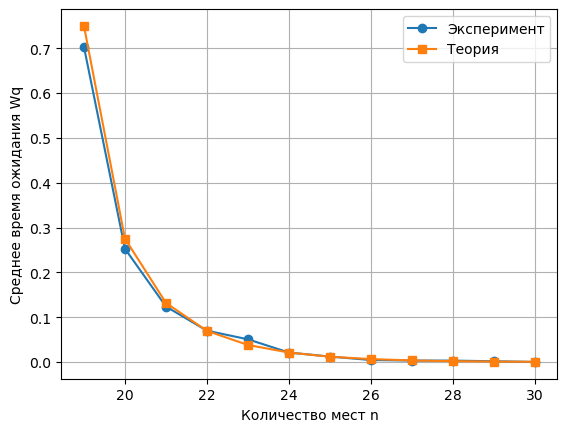

In [35]:
n_plot = [r["n"] for r in results_n]

wq_exp = [r["Wq (эксп)"] for r in results_n]
wq_theory = [r["Wq (теор)"] for r in results_n]

plt.figure()
plt.plot(n_plot, wq_exp, marker='o', label="Эксперимент")
plt.plot(n_plot, wq_theory, marker='s', label="Теория")
plt.xlabel("Количество мест n")
plt.ylabel("Среднее время ожидания Wq")
plt.legend()
plt.grid()
plt.show()

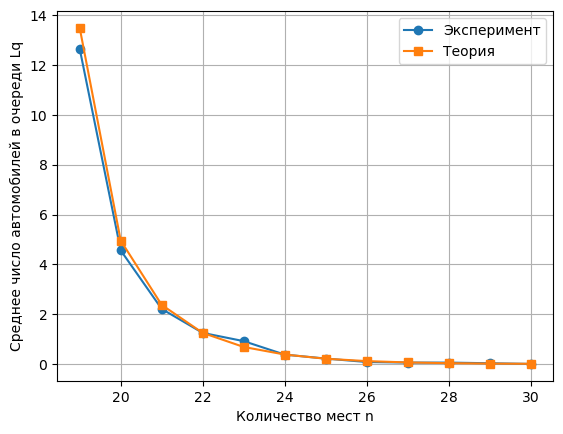

In [36]:
lq_exp = [r["Lq (эксп)"] for r in results_n]
lq_theory = [r["Lq (теор)"] for r in results_n]

plt.figure()
plt.plot(n_plot, lq_exp, marker='o', label="Эксперимент")
plt.plot(n_plot, lq_theory, marker='s', label="Теория")
plt.xlabel("Количество мест n")
plt.ylabel("Среднее число автомобилей в очереди Lq")
plt.legend()
plt.grid()
plt.show()

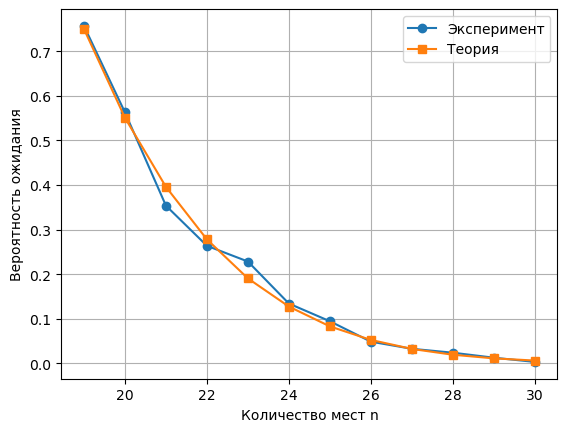

In [37]:
pwait_exp = [r["P ожидания (эксп)"] for r in results_n]
pwait_theory = [r["P ожидания (теор)"] for r in results_n]

plt.figure()
plt.plot(n_plot, pwait_exp, marker='o', label="Эксперимент")
plt.plot(n_plot, pwait_theory, marker='s', label="Теория")
plt.xlabel("Количество мест n")
plt.ylabel("Вероятность ожидания")
plt.legend()
plt.grid()
plt.show()

In [38]:
def run_mu_series(lmbda, n, mu_values, time_limit=10000.0, base_seed=42):
    results = []

    for i, mu in enumerate(mu_values):
        theory = mmn_inf_theory(lmbda, mu, n)
        sim = simulate_mmn_inf(lmbda, mu, n, time_limit, base_seed + i)

        results.append({
            "mu": mu,
            "P0 (эксп)": sim["p0_exp"],
            "P0 (теор)": theory["p0"],
            "P ожидания (эксп)": sim["p_wait_exp"],
            "P ожидания (теор)": theory["p_wait"],
            "Lq (эксп)": sim["lq_exp"],
            "Lq (теор)": theory["lq"],
            "Wq (эксп)": sim["wq_exp"],
            "Wq (теор)": theory["wq"],
            "Ws (эксп)": sim["ws_exp"],
            "Ws (теор)": theory["ws"],
            "Загрузка (эксп)": sim["load_coeff_exp"],
            "Загрузка (теор)": theory["load_coeff"]
        })

    return results

In [39]:
mu_values = np.arange(1.0, 2.1, 0.2)
results_mu = run_mu_series(LAMBDA_BASE, N_BASE, mu_values, TIME_LIMIT, SEED)

df_mu = pd.DataFrame(results_mu).round(6)
df_mu

,mu,P0 (эксп),P0 (теор),P ожидания (эксп),P ожидания (теор),Lq (эксп),Lq (теор),Wq (эксп),Wq (теор),Ws (эксп),Ws (теор),Загрузка (эксп),Загрузка (теор)
0,1.0,0.000134,0.000000,0.586760,0.550769,6.666625,4.956921,0.368995,0.275385,1.372514,1.275385,0.906530,0.900000
1,1.2,0.000009,0.000000,0.118835,0.160429,0.259639,0.481288,0.014568,0.026738,0.837315,0.860072,0.733191,0.750000
2,1.4,0.000021,0.000003,0.043837,0.045414,0.070725,0.081745,0.003939,0.004541,0.714349,0.718827,0.637699,0.642857
3,1.6,0.000042,0.000013,0.016261,0.012870,0.026004,0.016547,0.001448,0.000919,0.630736,0.625919,0.565006,0.562500
4,1.8,0.000079,0.000045,0.004094,0.003731,0.002811,0.003731,0.000155,0.000207,0.561677,0.555763,0.507531,0.500000
5,2.0,0.000248,0.000123,0.000449,0.001121,0.000205,0.000917,0.000011,0.000051,0.501513,0.500051,0.447139,0.450000


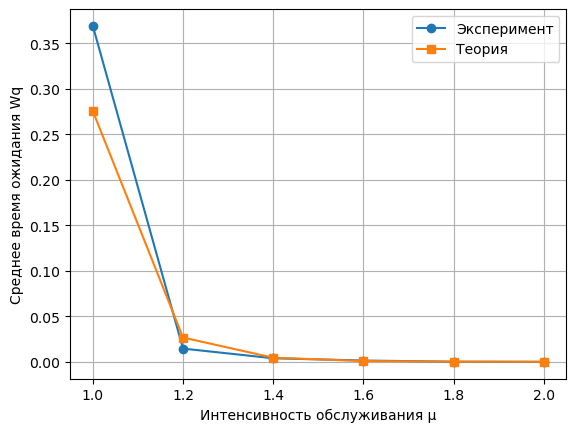

In [40]:
mu_plot = [r["mu"] for r in results_mu]

wq_mu_exp = [r["Wq (эксп)"] for r in results_mu]
wq_mu_theory = [r["Wq (теор)"] for r in results_mu]

plt.figure()
plt.plot(mu_plot, wq_mu_exp, marker='o', label="Эксперимент")
plt.plot(mu_plot, wq_mu_theory, marker='s', label="Теория")
plt.xlabel("Интенсивность обслуживания μ")
plt.ylabel("Среднее время ожидания Wq")
plt.legend()
plt.grid()
plt.show()

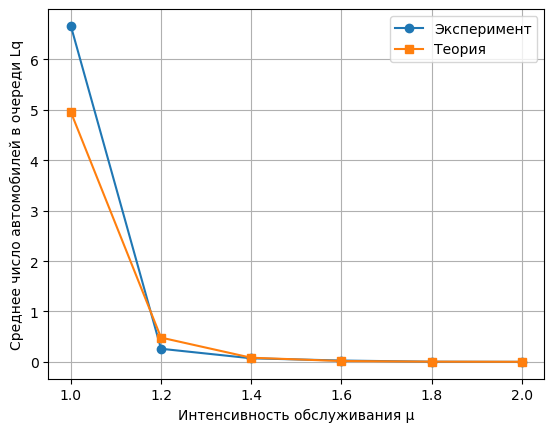

: 

In [ ]:
lq_mu_exp = [r["Lq (эксп)"] for r in results_mu]
lq_mu_theory = [r["Lq (теор)"] for r in results_mu]

plt.figure()
plt.plot(mu_plot, lq_mu_exp, marker='o', label="Эксперимент")
plt.plot(mu_plot, lq_mu_theory, marker='s', label="Теория")
plt.xlabel("Интенсивность обслуживания μ")
plt.ylabel("Среднее число автомобилей в очереди Lq")
plt.legend()
plt.grid()
plt.show()